In [1]:
from pathlib import Path

import scanpy as sc
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
import seaborn as sns

In [10]:
adata_orig_umap = sc.read_h5ad("output/adata_orig_umap.h5ad")
adata_st_umap = sc.read_h5ad("output/adata_st_whole_umap.h5ad")
adata_ft_umap = sc.read_h5ad("output/adata_ft_whole_umap.h5ad")

In [28]:
def run_scrublet(adata, expected_doublet_rate=0.25):
    sc.pp.scrublet(
        adata,
        expected_doublet_rate=expected_doublet_rate,
        random_state=0
    )
    
    # store percentage
    adata.uns["doublet_percent"] = (
        adata.obs["predicted_doublet"].mean() * 100
    )

In [29]:
run_scrublet(adata_orig_umap)
run_scrublet(adata_st_umap)
run_scrublet(adata_ft_umap)

/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


/var/folders/_2/50fjjk3d1696gqy3jz2ypb9j88m1t6/T/ipykernel_44000/284049001.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/var/folders/_2/50fjjk3d1696gqy3jz2ypb9j88m1t6/T/ipykernel_44000/284049001.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


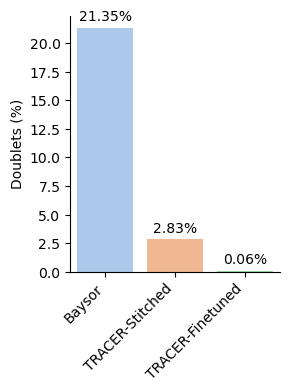

In [30]:
df = pd.DataFrame({
    "dataset": ["Baysor", "TRACER-Stitched", "TRACER-Finetuned"],
    "doublet_percent": [
        adata_orig_umap.uns["doublet_percent"],
        adata_st_umap.uns["doublet_percent"],
        adata_ft_umap.uns["doublet_percent"],
    ]
})

plt.figure(figsize=(3, 4))
ax = sns.barplot(
    data=df,
    x="dataset",
    y="doublet_percent",
    palette="pastel"
)

# Labels
plt.ylabel("Doublets (%)")
plt.xlabel("")

# Remove top and right spines (keep x/y axes)
sns.despine(ax=ax, top=True, right=True)

# Rotate x-axis labels
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha="right"
)

# Annotate bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.tight_layout()

# Save figure
plt.savefig("plot/scrublet_doublet_rate_exp_0.25.png", dpi=300, bbox_inches="tight")
plt.show()

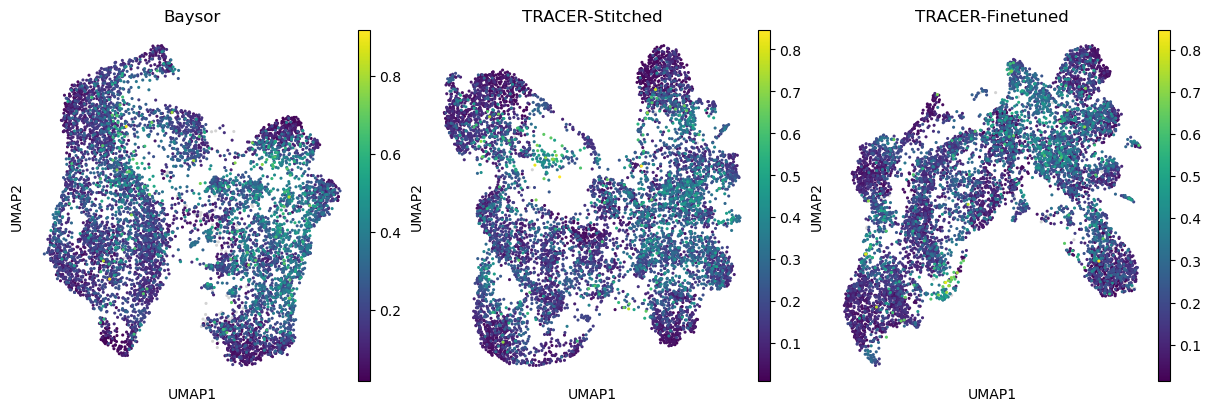

In [31]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 4),
    constrained_layout=True
)

datasets = [
    (adata_orig_umap, "Baysor"),
    (adata_st_umap,   "TRACER-Stitched"),
    (adata_ft_umap,   "TRACER-Finetuned"),
]

for ax, (adata, title) in zip(axes, datasets):
    sc.pl.umap(
        adata,
        color="doublet_score",
        ax=ax,
        show=False,
        title=title,
        palette=["lightgrey", "red"],
        size=20
    )

    # remove bounding box
    for spine in ax.spines.values():
        spine.set_visible(False)

    # remove ticks
    ax.set_xticks([])
    ax.set_yticks([])

plt.savefig("plot/scrublet_doublet_rate_umap_exp_0.25.png", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
df

,dataset,doublet_percent
0,Baysor,0.012425
1,TRACER-Stitched,0.000000
2,TRACER-Finetuned,0.000000


In [25]:
def run_scrublet(adata, expected_doublet_rate):
    sc.pp.scrublet(
        adata,
        expected_doublet_rate=expected_doublet_rate,
        random_state=0
    )
    return adata.obs["predicted_doublet"].mean() * 100

# Expected doublet rates to test
expected_rates = [0.005, 0.01, 0.1, 0.2, 0.25, 0.3]

# Datasets
datasets = {
    "Baysor": adata_orig_umap,
    "TRACER-Stitched": adata_st_umap,
    "TRACER-Finetuned": adata_ft_umap,
}

# Collect results
records = []

for dataset_name, adata in datasets.items():
    for rate in expected_rates:
        doublet_percent = run_scrublet(adata, rate)
        records.append({
            "dataset": dataset_name,
            "expected_doublet_rate": rate,
            "doublet_percent": doublet_percent
        })

df = pd.DataFrame(records)

/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


...

/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


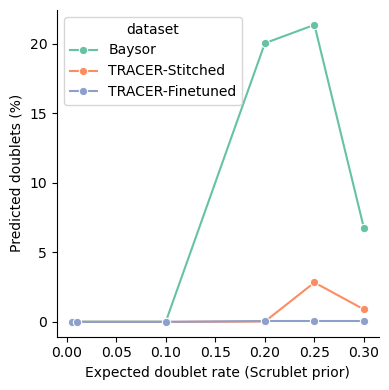

In [26]:
plt.figure(figsize=(4, 4))

ax = sns.lineplot(
    data=df,
    x="expected_doublet_rate",
    y="doublet_percent",
    hue="dataset",
    marker="o",
    palette="Set2"
)

plt.xlabel("Expected doublet rate (Scrublet prior)")
plt.ylabel("Predicted doublets (%)")

sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.show()


In [24]:
df

,dataset,expected_doublet_rate,doublet_percent
0,Baysor,0.005,None
1,Baysor,0.010,None
2,Baysor,0.100,None
3,Baysor,0.200,None
4,Baysor,0.250,None
5,Baysor,0.300,None
6,TRACER-Stitched,0.005,None
7,TRACER-Stitched,0.010,None
8,TRACER-Stitched,0.100,None
9,TRACER-Stitched,0.200,None
